# Pipeline Granger Estacionário

Carrega os presets sintéticos, estacionariza via ADF + diferenciação, verifica estacionaridade, executa Granger e exporta resultados.

In [ ]:
from __future__ import annotations

import os, sys
from pathlib import Path

# Hardcode repo root — works regardless of CWD
REPO_ROOT = Path("/home/rafael.ennes/Documents/mestrado/causalmmm_cdnots")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import adfuller

from causal_discovery.compare import (
    _load_preset, _PRESET_SPECS, _plot_adjacency_comparison,
)
from causal_discovery.algorithms.granger import discover as granger_discover
from causal_discovery.graph import CausalGraph

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("causal_discovery/results/stationary")
ADF_ALPHA = 0.05
MAX_DIFF = 2

print("OK")

: 

## 1. Funções de estacionarização

In [2]:
def stationarize(series: pd.Series, alpha: float = ADF_ALPHA) -> tuple[pd.Series, int]:
    """Diferencia a série até o ADF rejeitar raiz unitária (máx MAX_DIFF)."""
    s = series.dropna()
    for d in range(MAX_DIFF + 1):
        pval = adfuller(s, autolag="AIC")[1]
        if pval < alpha:
            return s, d
        s = s.diff().dropna()
    return s, MAX_DIFF


def stationarize_df(
    data: pd.DataFrame, var_names: list[str], alpha: float = ADF_ALPHA
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Estacionariza cada variável, alinha comprimentos."""
    diff_orders: dict[str, int] = {}
    stationary_cols: dict[str, pd.Series] = {}
    min_len = len(data)

    for col in var_names:
        s, d = stationarize(data[col], alpha)
        diff_orders[col] = d
        stationary_cols[col] = s.reset_index(drop=True)
        min_len = min(min_len, len(s))

    df_out = pd.DataFrame({c: stationary_cols[c].iloc[:min_len] for c in var_names})
    return df_out, diff_orders


def verify_stationarity(
    data: pd.DataFrame, var_names: list[str], alpha: float = ADF_ALPHA
) -> dict[str, float]:
    """Re-executa ADF pós-diferenciação. Avisa se alguma variável ainda não é estacionária."""
    adf_pvals = {}
    for col in var_names:
        pval = adfuller(data[col].dropna(), autolag="AIC")[1]
        adf_pvals[col] = pval
        if pval >= alpha:
            print(f"  WARNING: {col} ainda não estacionária (ADF p={pval:.4f})")
    return adf_pvals

## 2. Configuração dos presets

In [3]:
PRESETS = ["causal_business", "causal_large"]
ALPHA = 0.05
MAX_LAG = 2

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 3. Executar pipeline por preset

In [4]:
all_metrics = {}

for preset in PRESETS:
    print(f"\n{'='*60}")
    print(f"Preset: {preset}")
    print(f"{'='*60}")

    # --- 3a. Carregar dataset ---
    data_df, var_names, true_adj, truth_var_names = _load_preset(preset)
    print(f"  Variáveis: {var_names}")
    print(f"  Shape: {data_df.shape}")

    # --- 3b. Estacionarizar ---
    stat_df, diff_orders = stationarize_df(data_df, var_names)
    print(f"  Ordens de diferenciação: {diff_orders}")

    # --- 3c. Verificar estacionaridade ---
    adf_pvals = verify_stationarity(stat_df, var_names)
    n_fail = sum(1 for p in adf_pvals.values() if p >= ALPHA)
    print(f"  ADF check: {len(var_names) - n_fail}/{len(var_names)} estacionárias")

    # --- 3d. Executar Granger ---
    graph = granger_discover(stat_df, var_names, alpha=ALPHA, max_lag=MAX_LAG)
    print(f"  Granger concluído em {graph.runtime_seconds:.2f}s")

    # --- 3e. Avaliar contra ground truth ---
    eval_vars = list(truth_var_names)
    metrics = graph.evaluate(true_adj, var_subset=eval_vars)
    metrics["runtime_seconds"] = graph.runtime_seconds
    all_metrics[preset] = metrics
    print(f"  P={metrics['precision']:.3f}  R={metrics['recall']:.3f}  "
          f"F1={metrics['f1']:.3f}  SHD={metrics['shd']}")

    # --- 3f. Armazenar resultados ---
    preset_dir = OUTPUT_DIR / preset
    preset_dir.mkdir(parents=True, exist_ok=True)

    pd.DataFrame(
        graph.adjacency_matrix,
        index=graph.variable_names, columns=graph.variable_names,
    ).to_csv(preset_dir / "adjacency_matrix.csv")

    pd.DataFrame(
        true_adj,
        index=truth_var_names, columns=truth_var_names,
    ).to_csv(preset_dir / "true_adjacency_matrix.csv")

    pd.Series(diff_orders).to_csv(preset_dir / "diff_orders.csv", header=["order"])
    pd.Series(adf_pvals).to_csv(preset_dir / "adf_pvals_post.csv", header=["adf_pval"])

    # --- 3g. Plot da matriz de adjacência ---
    _plot_adjacency_comparison(
        {"stationary_granger": graph}, true_adj, truth_var_names, preset_dir,
    )
    print(f"  Plot salvo em {preset_dir / 'adjacency_comparison.png'}")


Preset: causal_business
  Variáveis: ['x1', 'x2', 'x3', 'x4', 'c1', 'y']
  Shape: (104, 6)
  Ordens de diferenciação: {'x1': 1, 'x2': 0, 'x3': 1, 'x4': 0, 'c1': 0, 'y': 1}
  ADF check: 6/6 estacionárias


  Granger concluído em 0.07s
  P=0.800  R=0.800  F1=0.800  SHD=2


/tmp/ipykernel_2481763/3778827265.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  pval = adfuller(s, autolag="AIC")[1]
/tmp/ipykernel_2481763/3778827265.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  pval = adfuller(s, autolag="AIC")[1]
/tmp/ipykernel_2481763/3778827265.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the stor

  Plot salvo em causal_discovery/results/stationary/causal_business/adjacency_comparison.png

Preset: causal_large
  Variáveis: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'c1', 'c2', 'c3', 'y']
  Shape: (260, 14)
  Ordens de diferenciação: {'x1': 1, 'x2': 1, 'x3': 1, 'x4': 1, 'x5': 1, 'x6': 1, 'x7': 0, 'x8': 1, 'x9': 1, 'x10': 1, 'c1': 0, 'c2': 0, 'c3': 0, 'y': 1}
  ADF check: 14/14 estacionárias


/tmp/ipykernel_2481763/3778827265.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  pval = adfuller(s, autolag="AIC")[1]
/tmp/ipykernel_2481763/3778827265.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  pval = adfuller(s, autolag="AIC")[1]
/tmp/ipykernel_2481763/3778827265.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the stor

  Granger concluído em 0.41s
  P=0.750  R=0.231  F1=0.353  SHD=11


  Plot salvo em causal_discovery/results/stationary/causal_large/adjacency_comparison.png


## 4. Métricas consolidadas

In [5]:
metrics_df = pd.DataFrame(all_metrics).T
metrics_df.to_csv(OUTPUT_DIR / "metrics.csv")
metrics_df

,precision,recall,f1,fdr,shd,tp,fp,fn,tn,runtime_seconds
causal_business,0.80,0.800000,0.800000,0.20,2.0,4.0,1.0,1.0,14.0,0.065953
causal_large,0.75,0.230769,0.352941,0.25,11.0,3.0,1.0,10.0,96.0,0.414834


## 5. Visualizar matrizes de adjacência


--- causal_business ---


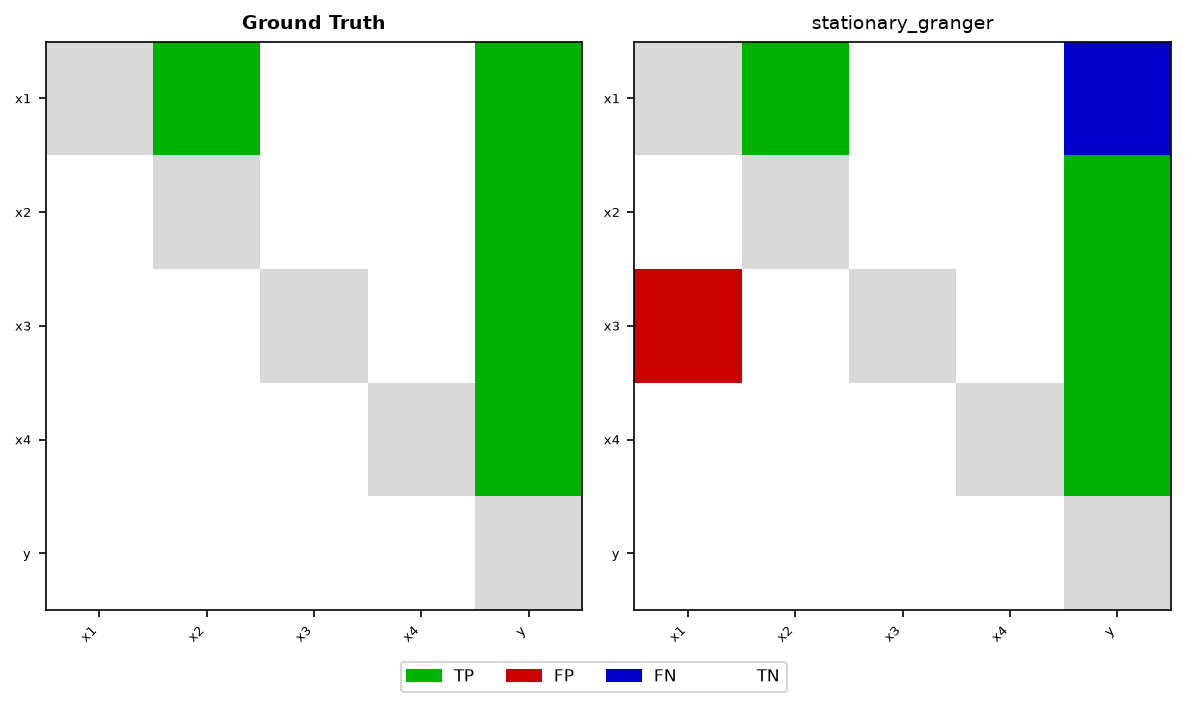


--- causal_large ---


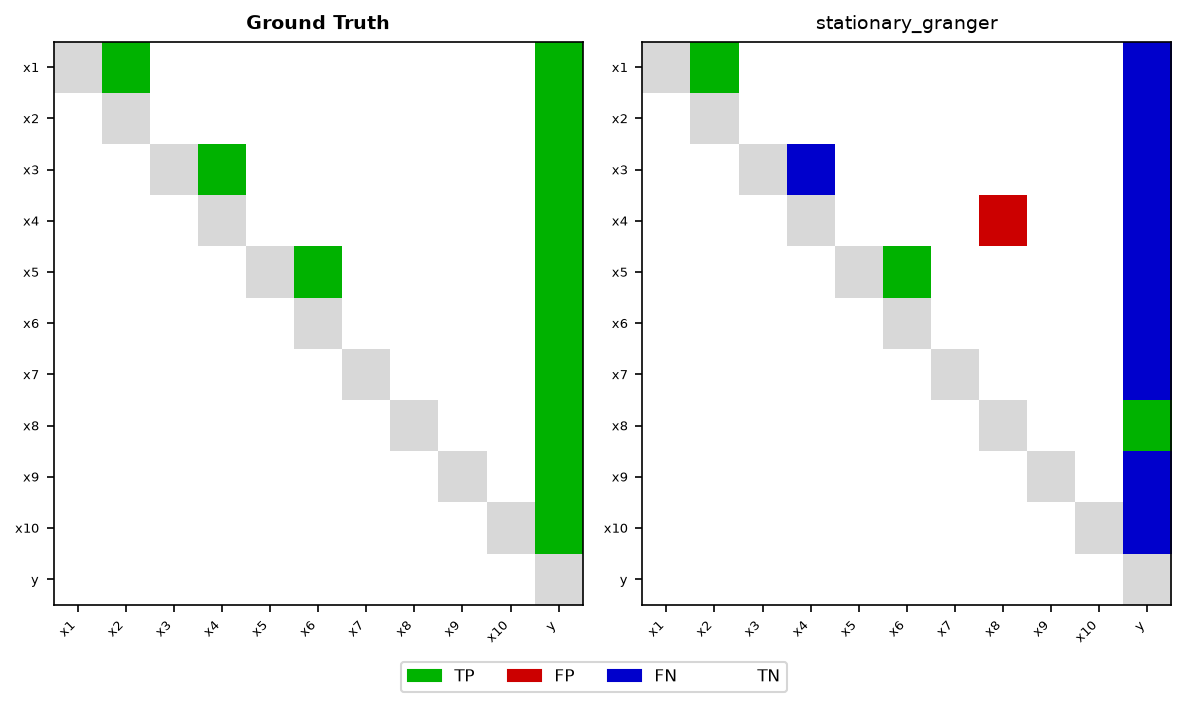

In [6]:
from IPython.display import display, Image

for preset in PRESETS:
    img_path = OUTPUT_DIR / preset / "adjacency_comparison.png"
    if img_path.exists():
        print(f"\n--- {preset} ---")
        display(Image(filename=str(img_path)))